<a href="https://colab.research.google.com/github/Giraffe-Shin/trading/blob/main/german_elec_predic_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import requests
from io import StringIO
from google.colab import userdata

# --- 필수 설정 ---
try:
    # Colab 보안 비밀(Secrets)에서 토큰을 가져옵니다.
    github_token = userdata.get('GITHUB_TOKEN')
except Exception:
    github_token = 'YOUR_TOKEN_HERE'

username = 'Giraffe-Shin'
repo = 'trading'
branch = 'main'
file_path = 'germany_energy_master.csv'

# API를 통한 프라이빗 파일 접근 URL
url = f'https://raw.githubusercontent.com/{username}/{repo}/{branch}/{file_path}'

headers = {'Authorization': f'token {github_token}'}

try:
    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        df = pd.read_csv(StringIO(response.text))
        print("성공적으로 파일을 불러왔습니다!")
        display(df.head())
    elif response.status_code == 401:
        print("인증 실패: 토큰이 유효하지 않거나 권한이 없습니다.")
    elif response.status_code == 404:
        print("파일을 찾을 수 없습니다(404). 토큰 이름, 경로, 브랜치명을 다시 확인해주세요.")
    else:
        print(f"실패했습니다. 상태 코드: {response.status_code}")
except Exception as e:
    print(f"오류 발생: {e}")

성공적으로 파일을 불러왔습니다!


,Unnamed: 0,Hydro pumped storage consumption,Cross border electricity trading,Nuclear,Hydro Run-of-River,Biomass,Fossil brown coal / lignite,Fossil hard coal,Fossil oil,Fossil coal-derived gas,...,Luxembourg,Netherlands,Norway,Poland,Sweden,Switzerland,sum,ren_share_daily_avg,Price_quarterhour,Price_hour
0,2022-12-31 23:00:00,-1975.8,-12645.2,2460.7,1627.7,4022.8,3845.6,1825.5,306.0,670.0,...,-0.335,-0.852,-1.289,-0.020,-0.519,-0.792,-12.645,NaN,NaN,NaN
1,2022-12-31 23:15:00,-2009.5,-12544.0,2458.5,1624.8,4012.0,3847.7,1828.6,306.8,648.2,...,-0.335,-0.852,-1.289,-0.020,-0.519,-0.792,-12.544,NaN,NaN,NaN
2,2022-12-31 23:30:00,-2244.0,-12526.2,2459.6,1624.8,4010.0,3860.2,1825.2,306.9,648.2,...,-0.335,-0.852,-1.289,-0.020,-0.519,-0.792,-12.526,NaN,NaN,NaN
3,2022-12-31 23:45:00,-2077.3,-12515.4,2457.9,1622.0,4004.0,3861.6,1819.7,306.0,639.1,...,-0.335,-0.852,-1.289,-0.020,-0.519,-0.792,-12.515,NaN,NaN,NaN
4,2023-01-01 00:00:00,-1204.1,-15410.1,2457.7,1622.3,3988.4,3869.8,1811.4,306.0,635.0,...,-0.320,-1.625,-1.289,-0.734,-0.519,-0.799,-15.410,85.1,NaN,NaN


In [19]:
# 가격 관련 컬럼 선택
price_columns = ['Price_quarterhour', 'Price_hour']

# ffill()을 사용하여 결측치 채우기
df[price_columns] = df[price_columns].ffill()

# 결과 확인
print("--- ffill 적용 후 가격 컬럼 결측치 상태 ---")
print(df[price_columns].isnull().sum())

# 데이터 샘플 출력
display(df[price_columns].tail())

--- ffill 적용 후 가격 컬럼 결측치 상태 ---
Price_quarterhour    96
Price_hour           96
dtype: int64


,Price_quarterhour,Price_hour
69979,2.44,2.44
69980,2.44,2.44
69981,2.44,2.44
69982,2.44,2.44
69983,2.44,2.44


In [20]:
# 데이터의 정확한 컬럼명을 확인합니다.
print("사용 가능한 컬럼 목록:")
print(df.columns.tolist())

# 컬럼명을 확인한 후, 실제 부하와 예측 부하에 해당하는 이름을 아래에 설정해주세요.
# 현재 출력된 결과에서 'Actual'과 'Forecast' 혹은 'Load'와 관련된 명칭을 찾으시면 됩니다.

사용 가능한 컬럼 목록:
['Unnamed: 0', 'Hydro pumped storage consumption', 'Cross border electricity trading', 'Nuclear', 'Hydro Run-of-River', 'Biomass', 'Fossil brown coal / lignite', 'Fossil hard coal', 'Fossil oil', 'Fossil coal-derived gas', 'Fossil gas', 'Geothermal', 'Hydro water reservoir', 'Hydro pumped storage', 'Others', 'Waste', 'Wind offshore', 'Wind onshore', 'Solar', 'Load', 'Residual load', 'Renewable share of load', 'Renewable share of generation', 'solar_mw', 'wind_onshore_mw', 'wind_offshore_mw', 'load_mw', 'Austria', 'Belgium', 'Czech Republic', 'Denmark', 'France', 'Luxembourg', 'Netherlands', 'Norway', 'Poland', 'Sweden', 'Switzerland', 'sum', 'ren_share_daily_avg', 'Price_quarterhour', 'Price_hour']


In [21]:
df_load = df.copy()
df_load.index = pd.to_datetime(df_load['Unnamed: 0'])
df_load.drop('Unnamed: 0', axis=1, inplace=True)
df_load.index.name = None
df_load = df_load[['Load', 'load_mw']]
display(df_load.head(30))

,Load,load_mw
2022-12-31 23:00:00,38691.8,42608.5
2022-12-31 23:15:00,38374.2,42152.1
2022-12-31 23:30:00,38248.0,41520.1
2022-12-31 23:45:00,38070.2,40889.2
2023-01-01 00:00:00,37733.4,40431.3
2023-01-01 00:15:00,37634.4,39862.1
2023-01-01 00:30:00,38043.5,39342.1
2023-01-01 00:45:00,37697.5,38849.3
2023-01-01 01:00:00,37277.4,38663.0
2023-01-01 01:15:00,37067.2,38550.8


--- 예측 오차 분석 요약 ---
평균 절대 오차 (MAE): 1951.71 MW
평균 제곱근 오차 (RMSE): 2403.48 MW
평균 절대 백분율 오차 (MAPE): 3.81%
오차 평균 (Bias): -171.44 MW


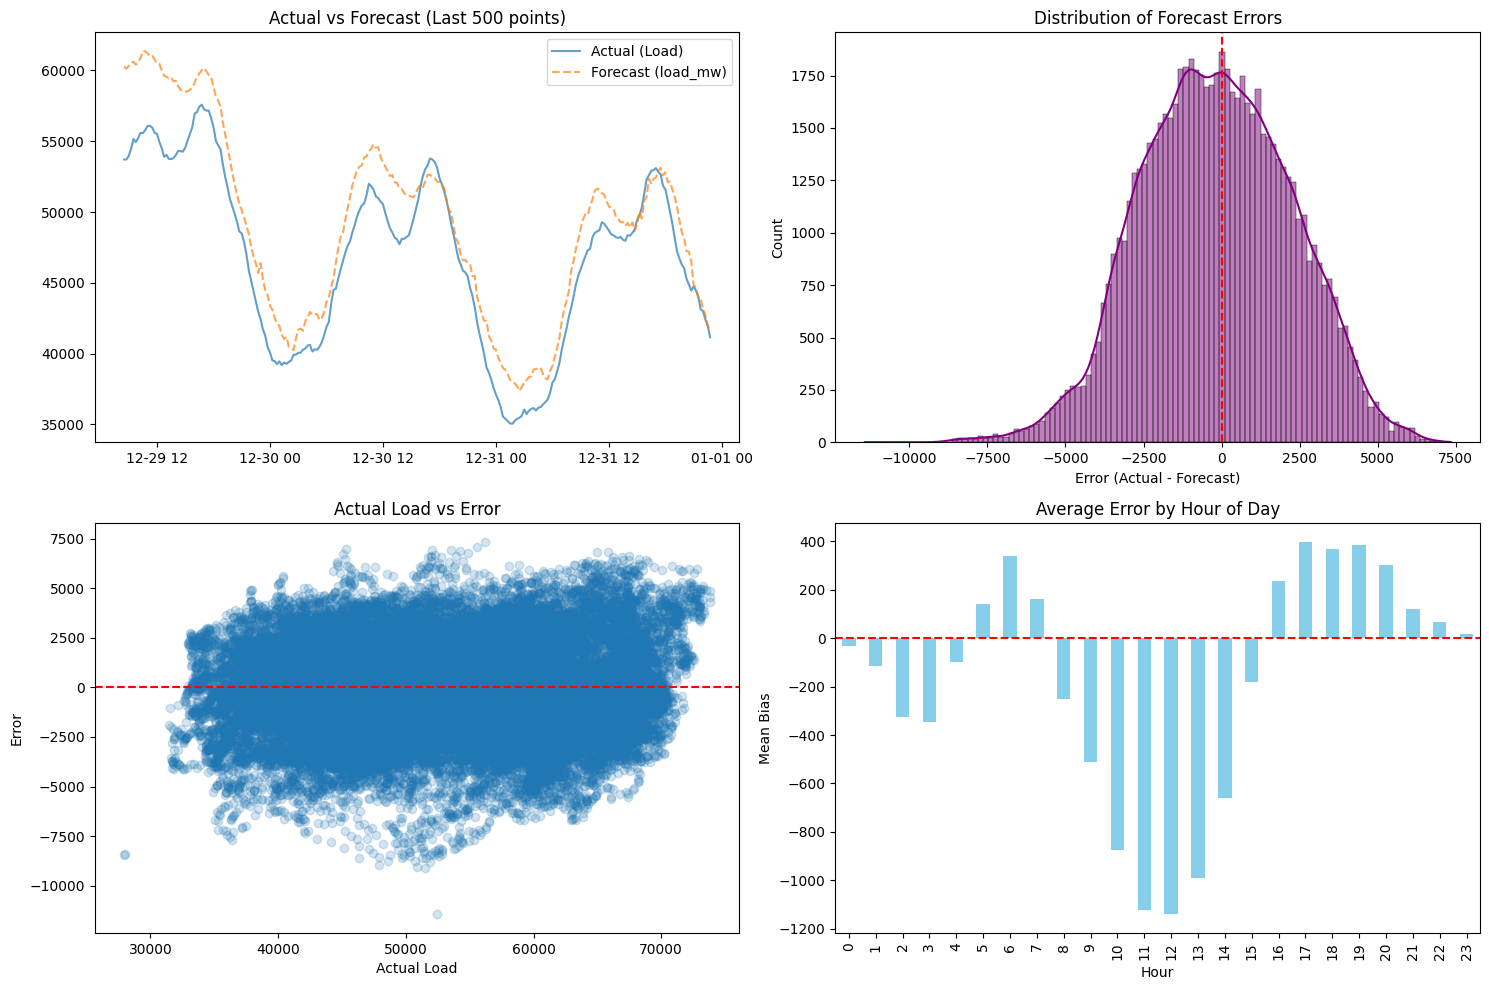

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 오차 계산 (Error = Actual - Forecast)
df_load['error'] = df_load['Load'] - df_load['load_mw']
df_load['abs_error'] = df_load['error'].abs()

# 2. 주요 통계 지표 산출
mae = df_load['abs_error'].mean()
mse = (df_load['error']**2).mean()
rmse = np.sqrt(mse)
mape = (df_load['abs_error'] / df_load['Load']).mean() * 100

print(f"--- 예측 오차 분석 요약 ---")
print(f"평균 절대 오차 (MAE): {mae:.2f} MW")
print(f"평균 제곱근 오차 (RMSE): {rmse:.2f} MW")
print(f"평균 절대 백분율 오차 (MAPE): {mape:.2f}%")
print(f"오차 평균 (Bias): {df_load['error'].mean():.2f} MW") # 0에 가까울수록 편향이 적음

# 3. 시각화 분석
plt.figure(figsize=(15, 10))

# (1) 실제값 vs 예측값 시계열 샘플 (최근 500개)
plt.subplot(2, 2, 1)
plt.plot(df_load.index[-500:], df_load['Load'].iloc[-500:], label='Actual (Load)', alpha=0.7)
plt.plot(df_load.index[-500:], df_load['load_mw'].iloc[-500:], label='Forecast (load_mw)', alpha=0.7, linestyle='--')
plt.title('Actual vs Forecast (Last 500 points)')
plt.legend()

# (2) 오차 분포 (Residual Distribution)
plt.subplot(2, 2, 2)
sns.histplot(df_load['error'], kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Forecast Errors')
plt.xlabel('Error (Actual - Forecast)')

# (3) 실제값 대비 오차 산점도 (Homoscedasticity 확인)
plt.subplot(2, 2, 3)
plt.scatter(df_load['Load'], df_load['error'], alpha=0.1)
plt.axhline(0, color='red', linestyle='--')
plt.title('Actual Load vs Error')
plt.xlabel('Actual Load')
plt.ylabel('Error')

# (4) 시간대별 평균 오차 (시간적 패턴 분석)
df_load['hour'] = df_load.index.hour
hourly_error = df_load.groupby('hour')['error'].mean()

plt.subplot(2, 2, 4)
hourly_error.plot(kind='bar', color='skyblue')
plt.axhline(0, color='red', linestyle='--')
plt.title('Average Error by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Mean Bias')

plt.tight_layout()
plt.show()

--- 2023년 월별 부하 합계 대비 오차 비율 ---
              Load   abs_error  error_rate_pct
month                                         
1      333530870.0  14384367.6            4.31
2      305086604.2   8208037.0            2.69
3      327332091.0  14084302.4            4.30
4      289133808.0   9642783.8            3.34
5      290683148.2  10394153.0            3.58
6      283757002.8  10973943.2            3.87
7      290042564.8   7445745.6            2.57
8      290495162.6  10260213.0            3.53
9      286388088.2  10815260.8            3.78
10     310127072.8  12254288.6            3.95
11     328803678.0  14100452.6            4.29
12     327570979.2  14011195.2            4.28

비율상 가장 오차가 컸던 달: 1월 (4.31%)


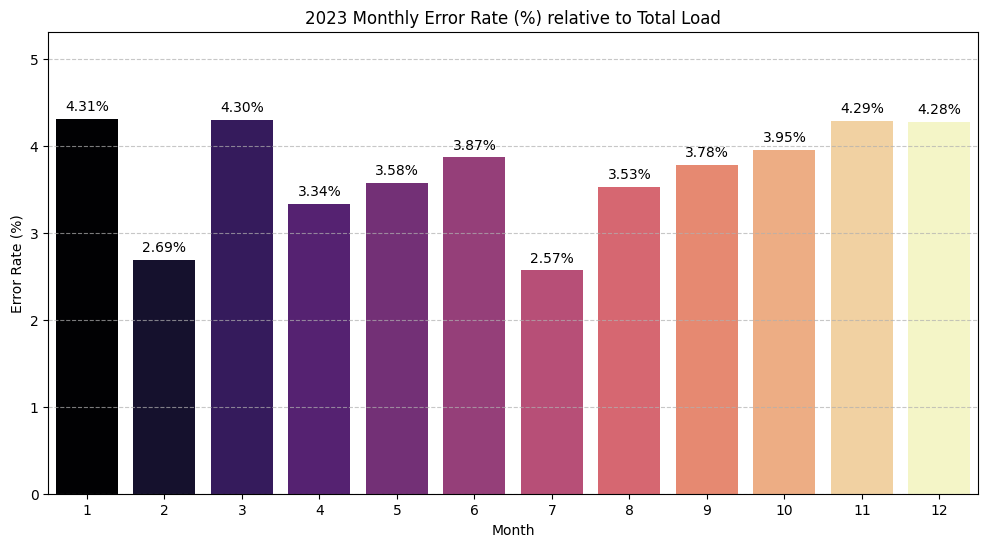

In [6]:
# 2023년 월별 합계 기반 오차 비율 분석
df_2023 = df_load[df_load.index.year == 2023].copy()
df_2023['month'] = df_2023.index.month

# 월별 실제 Load 합계와 절대 오차 합계 계산
monthly_stats = df_2023.groupby('month').agg({
    'Load': 'sum',
    'abs_error': 'sum'
})

# 오차 비율 (%) 계산: (오차 합계 / 실제 부하 합계) * 100
monthly_stats['error_rate_pct'] = (monthly_stats['abs_error'] / monthly_stats['Load']) * 100

print("--- 2023년 월별 부하 합계 대비 오차 비율 ---")
print(monthly_stats[['Load', 'abs_error', 'error_rate_pct']].round(2))

# 가장 비율이 높았던 달 확인
max_rate_month = monthly_stats['error_rate_pct'].idxmax()
max_rate_value = monthly_stats['error_rate_pct'].max()

print(f"\n비율상 가장 오차가 컸던 달: {max_rate_month}월 ({max_rate_value:.2f}%)")

# 월별 오차 비율 시각화
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=monthly_stats.index, y=monthly_stats['error_rate_pct'], hue=monthly_stats.index, palette='magma', legend=False)

# 바 위에 수치 표시
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.title('2023 Monthly Error Rate (%) relative to Total Load')
plt.xlabel('Month')
plt.ylabel('Error Rate (%)')
plt.ylim(0, monthly_stats['error_rate_pct'].max() + 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [7]:
# 신재생 에너지 실제값과 예측값 추출
renewable_cols = [
    'Wind offshore', 'Wind onshore', 'Solar',             # 실제 발전량
    'solar_mw', 'wind_onshore_mw', 'wind_offshore_mw'    # 예측 발전량
]

df_renewable = df.copy()
df_renewable.index = pd.to_datetime(df_renewable['Unnamed: 0'])
df_renewable.drop('Unnamed: 0', axis=1, inplace=True)
df_renewable.index.name = None

# 요청하신 컬럼만 선택
df_renewable = df_renewable[renewable_cols]

print("df_renewable 데이터프레임이 생성되었습니다.")
display(df_renewable.head())

df_renewable 데이터프레임이 생성되었습니다.


,Wind offshore,Wind onshore,Solar,solar_mw,wind_onshore_mw,wind_offshore_mw
2022-12-31 23:00:00,2739.0,27260.9,0.0,0.0,34775.4,3468.6
2022-12-31 23:15:00,2975.6,27311.5,0.0,0.0,35861.2,3477.2
2022-12-31 23:30:00,3269.6,27699.4,0.0,0.0,35775.8,3480.8
2022-12-31 23:45:00,3259.5,27170.0,0.0,0.0,35649.6,3485.7
2023-01-01 00:00:00,3144.1,27853.6,0.0,0.0,35474.3,3381.6


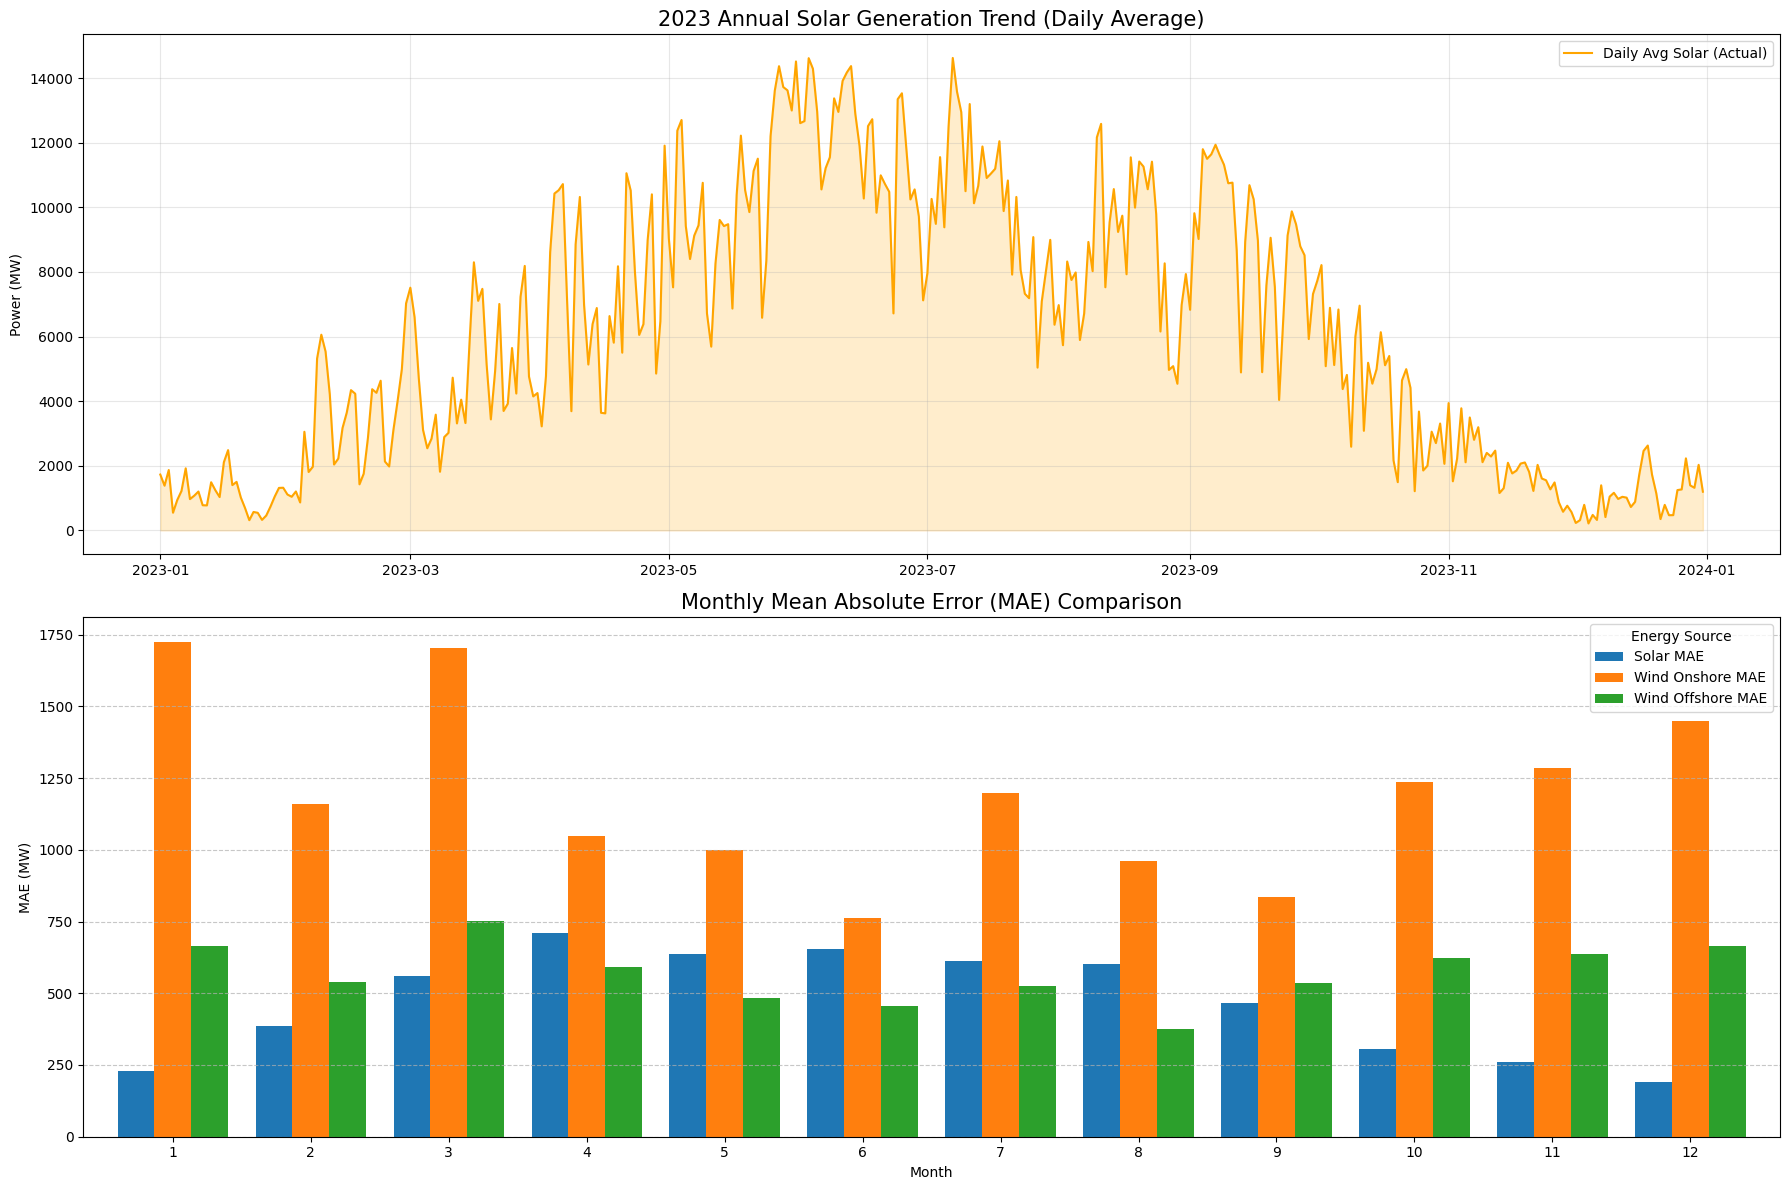

--- 2023년 월별 예측 오차(MAE 및 %) 요약 ---


,Solar MAE (MW),Solar Error (%),Wind On MAE (MW),Wind On Error (%),Wind Off MAE (MW),Wind Off Error (%)
month,,,,,,
1,230.30,20.50,1725.11,9.30,663.81,18.15
2,386.45,11.61,1160.96,7.78,540.61,22.19
3,560.30,11.63,1704.76,10.95,753.21,22.94
4,709.32,9.60,1047.78,9.16,592.13,24.62
5,635.36,6.15,997.99,11.46,485.16,22.74
6,653.12,5.53,763.60,11.53,455.93,27.57
7,612.24,6.12,1197.93,10.75,523.71,21.77
8,601.35,7.02,959.38,12.62,375.85,23.38
9,465.53,5.21,835.35,11.42,536.27,28.93


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 2023년 데이터 필터링 및 월별 오차 계산
df_renewable_2023 = df_renewable[df_renewable.index.year == 2023].copy()
df_renewable_2023['month'] = df_renewable_2023.index.month

# 에너지원별 절대 오차 계산
df_renewable_2023['Solar_abs_err'] = (df_renewable_2023['Solar'] - df_renewable_2023['solar_mw']).abs()
df_renewable_2023['Wind_On_abs_err'] = (df_renewable_2023['Wind onshore'] - df_renewable_2023['wind_onshore_mw']).abs()
df_renewable_2023['Wind_Off_abs_err'] = (df_renewable_2023['Wind offshore'] - df_renewable_2023['wind_offshore_mw']).abs()

# 월별 평균 발전량 및 MAE 집계
monthly_renewable = df_renewable_2023.groupby('month').agg({
    'Solar': 'mean',
    'Wind onshore': 'mean',
    'Wind offshore': 'mean',
    'Solar_abs_err': 'mean',
    'Wind_On_abs_err': 'mean',
    'Wind_Off_abs_err': 'mean'
})

# 퍼센테이지(%) 오차율 계산
monthly_renewable['Solar Error %'] = (monthly_renewable['Solar_abs_err'] / monthly_renewable['Solar']) * 100
monthly_renewable['Wind Onshore Error %'] = (monthly_renewable['Wind_On_abs_err'] / monthly_renewable['Wind onshore']) * 100
monthly_renewable['Wind Offshore Error %'] = (monthly_renewable['Wind_Off_abs_err'] / monthly_renewable['Wind offshore']) * 100

# 2. 시각화
plt.figure(figsize=(18, 12))

# (1) Solar 1년 추이
plt.subplot(2, 1, 1)
daily_solar = df_renewable_2023['Solar'].resample('D').mean()
plt.plot(daily_solar.index, daily_solar.values, color='orange', label='Daily Avg Solar (Actual)')
plt.fill_between(daily_solar.index, daily_solar.values, color='orange', alpha=0.2)
plt.title('2023 Annual Solar Generation Trend (Daily Average)', fontsize=15)
plt.ylabel('Power (MW)')
plt.grid(True, alpha=0.3)
plt.legend()

# (2) 월별 에너지원별 예측 오차(MAE) 비교
plt.subplot(2, 1, 2)
monthly_mae = monthly_renewable[['Solar_abs_err', 'Wind_On_abs_err', 'Wind_Off_abs_err']]
monthly_mae.columns = ['Solar MAE', 'Wind Onshore MAE', 'Wind Offshore MAE']

monthly_mae.plot(kind='bar', ax=plt.gca(), width=0.8)
plt.title('Monthly Mean Absolute Error (MAE) Comparison', fontsize=15)
plt.xlabel('Month')
plt.ylabel('MAE (MW)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Energy Source')

plt.tight_layout()
plt.show()

# 3. 데이터 테이블 정리 및 출력
summary_table = monthly_renewable[[
    'Solar_abs_err', 'Solar Error %',
    'Wind_On_abs_err', 'Wind Onshore Error %',
    'Wind_Off_abs_err', 'Wind Offshore Error %'
]]
summary_table.columns = [
    'Solar MAE (MW)', 'Solar Error (%)',
    'Wind On MAE (MW)', 'Wind On Error (%)',
    'Wind Off MAE (MW)', 'Wind Off Error (%)'
]

print("--- 2023년 월별 예측 오차(MAE 및 %) 요약 ---")
display(summary_table.round(2))

### Step 3-1: XGBoost 베이스라인 모델 구현

시계열 데이터의 특성을 반영하기 위해 `Unnamed: 0` 컬럼에서 시간 정보를 추출하고, XGBoost 모델을 학습시킵니다.

In [22]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. 피처 엔지니어링: 시간 관련 변수 생성 및 타겟 설정
df_ml = df.copy()
df_ml['timestamp'] = pd.to_datetime(df_ml['Unnamed: 0'])
df_ml['hour'] = df_ml['timestamp'].dt.hour
df_ml['day_of_week'] = df_ml['timestamp'].dt.dayofweek
df_ml['month'] = df_ml['timestamp'].dt.month

# 2. 독립 변수(X)와 종속 변수(y) 설정
# 사용자 요청: forecast load, forecast solar, wind on/off
features = [
    'hour', 'day_of_week', 'month',
    'load_mw', 'solar_mw', 'wind_onshore_mw', 'wind_offshore_mw'
]
target = 'Price_hour'

# 결측치 제거 (ffill 후에도 남은 초기 결측치 등 처리)
df_ml = df_ml.dropna(subset=features + [target])

X = df_ml[features]
y = df_ml[target]

# 3. 시계열 분할 (8:2)
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# 4. XGBoost 모델 학습
xgb_price_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_price_model.fit(X_train, y_train)

# 5. 예측 및 평가
y_pred = xgb_price_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- XGBoost Price Prediction Performance ---")
print(f"MAE: {mae:.2f} (Price Unit)")
print(f"RMSE: {rmse:.2f} (Price Unit)")

--- XGBoost Price Prediction Performance ---
MAE: 20.54 (Price Unit)
RMSE: 25.93 (Price Unit)


베이스라인 모델이 완성되었습니다. 이제 **Step 4: Granular Parameter Tuning**으로 넘어가서 `max_depth`, `learning_rate`, `n_estimators` 등을 최적화해 볼까요? 아니면 바로 결과를 시각화해 볼까요?

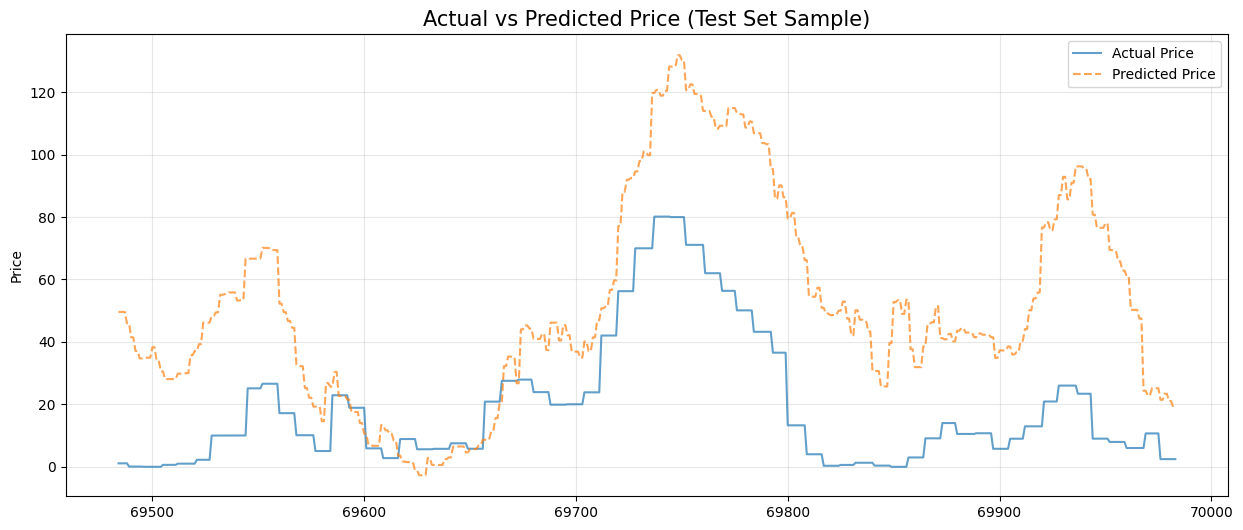

/tmp/ipykernel_2995/1037184193.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(features)[indices], palette='viridis')


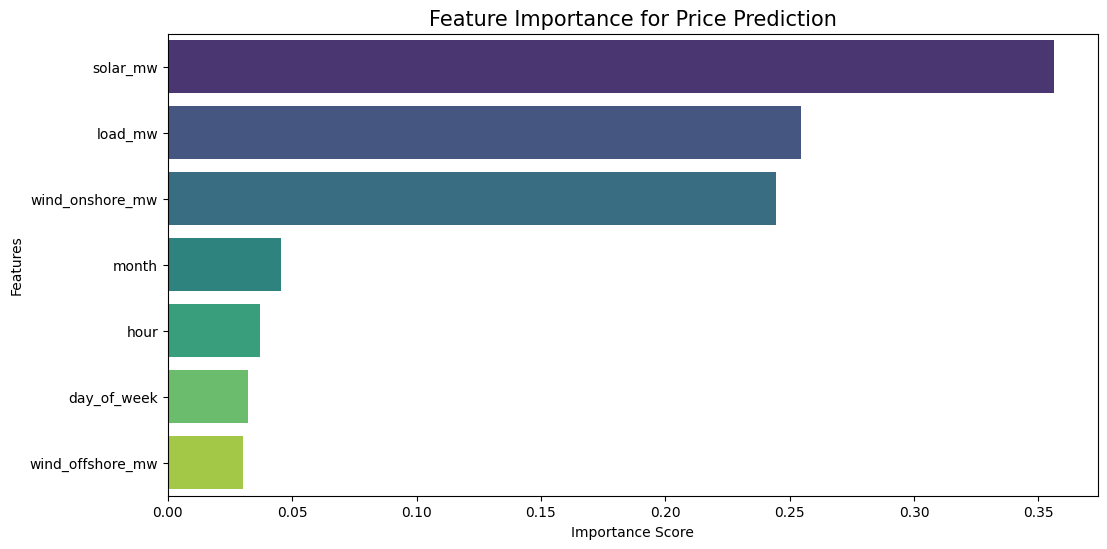

--- 분석 결과 Summary ---
가장 영향력이 높은 변수: solar_mw
두 번째로 영향력이 높은 변수: load_mw


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 실제값 vs 예측값 시각화 (테스트 데이터 중 마지막 1주일/500개 샘플)
plt.figure(figsize=(15, 6))
plt.plot(y_test.index[-500:], y_test.values[-500:], label='Actual Price', alpha=0.7)
plt.plot(y_test.index[-500:], y_pred[-500:], label='Predicted Price', alpha=0.7, linestyle='--')
plt.title('Actual vs Predicted Price (Test Set Sample)', fontsize=15)
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. 피처 중요도(Feature Importance) 확인
importances = xgb_price_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices], y=np.array(features)[indices], palette='viridis')
plt.title('Feature Importance for Price Prediction', fontsize=15)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

print("--- 분석 결과 Summary ---")
print(f"가장 영향력이 높은 변수: {features[indices[0]]}")
print(f"두 번째로 영향력이 높은 변수: {features[indices[1]]}")

In [24]:
import json
import numpy as np

# 1. D3.js용 데이터 추출 및 저장
# 실제값 vs 예측값 (최근 100개 데이터로 제한하여 가독성 확보)
chart_data = []
test_indices = y_test.index[-100:].astype(str).tolist()
actual_values = y_test.values[-100:].tolist()
pred_values = y_pred[-100:].tolist()

for i in range(len(test_indices)):
    chart_data.append({
        "date": test_indices[i],
        "actual": float(actual_values[i]),
        "predicted": float(pred_values[i])
    })

# 피처 중요도 데이터
importances = xgb_price_model.feature_importances_
feat_importance_data = [
    {"feature": feat, "importance": float(imp)}
    for feat, imp in zip(features, importances)
]
feat_importance_data = sorted(feat_importance_data, key=lambda x: x['importance'], reverse=True)

# JSON 저장
dashboard_json = {
    "time_series": chart_data,
    "importance": feat_importance_data
}

with open('dashboard_data.json', 'w') as f:
    json.dump(dashboard_json, f)

# 2. index.html 파일 생성 (D3.js 대시보드)
html_content = """<!DOCTYPE html>
<html>
<head>
    <meta charset='utf-8'>
    <title>XGBoost Price Prediction Dashboard</title>
    <script src='https://d3js.org/d3.v7.min.js'></script>
    <style>
        body { font-family: sans-serif; margin: 40px; background-color: #f5f5f5; }
        .container { display: flex; flex-direction: column; gap: 50px; background: white; padding: 30px; border-radius: 8px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); }
        .line-actual { fill: none; stroke: #3498db; stroke-width: 2; }
        .line-pred { fill: none; stroke: #e74c3c; stroke-width: 2; stroke-dasharray: 4; }
        .axis-label { font-size: 12px; }
        .bar { fill: #2ecc71; }
        h2 { color: #2c3e50; border-bottom: 2px solid #eee; padding-bottom: 10px; }
    </style>
</head>
<body>
    <div class='container'>
        <div>
            <h2>Price Prediction: Actual vs Predicted</h2>
            <div id='timeseries'></div>
        </div>
        <div>
            <h2>Feature Importance</h2>
            <div id='importance'></div>
        </div>
    </div>

    <script>
        d3.json('dashboard_data.json').then(data => {
            // 1. Time Series Chart
            const margin = {top: 20, right: 30, bottom: 50, left: 50}, width = 900 - margin.left - margin.right, height = 400 - margin.top - margin.bottom;
            const svg1 = d3.select('#timeseries').append('svg').attr('width', width + margin.left + margin.right).attr('height', height + margin.top + margin.bottom).append('g').attr('transform', `translate(${margin.left},${margin.top})`);

            const x = d3.scalePoint().domain(data.time_series.map(d => d.date)).range([0, width]);
            const y = d3.scaleLinear().domain([0, d3.max(data.time_series, d => Math.max(d.actual, d.predicted)) * 1.1]).range([height, 0]);

            svg1.append('g').attr('transform', `translate(0,${height})`).call(d3.axisBottom(x).tickValues(x.domain().filter((d,i) => !(i%10)))).selectAll('text').style('text-anchor', 'end').attr('transform', 'rotate(-45)');
            svg1.append('g').call(d3.axisLeft(y));

            svg1.append('path').datum(data.time_series).attr('class', 'line-actual').attr('d', d3.line().x(d => x(d.date)).y(d => y(d.actual)));
            svg1.append('path').datum(data.time_series).attr('class', 'line-pred').attr('d', d3.line().x(d => x(d.date)).y(d => y(d.predicted)));

            // 2. Feature Importance Chart
            const svg2 = d3.select('#importance').append('svg').attr('width', width + margin.left + margin.right).attr('height', 300).append('g').attr('transform', `translate(${margin.left + 50},20)`);
            const xImp = d3.scaleLinear().domain([0, d3.max(data.importance, d => d.importance)]).range([0, width - 100]);
            const yImp = d3.scaleBand().domain(data.importance.map(d => d.feature)).range([0, 250]).padding(0.1);

            svg2.append('g').call(d3.axisLeft(yImp));
            svg2.selectAll('.bar').data(data.importance).enter().append('rect').attr('class', 'bar').attr('y', d => yImp(d.feature)).attr('height', yImp.bandwidth()).attr('x', 0).attr('width', d => xImp(d.importance));
        });
    </script>
</body>
</html>"""

with open('index.html', 'w') as f:
    f.write(html_content)

print("파일 생성 완료!")
print("1. dashboard_data.json")
print("2. index.html")
print("위 두 파일을 다운로드하여 깃허브 리포지토리에 업로드하세요.")

파일 생성 완료!
1. dashboard_data.json
2. index.html
위 두 파일을 다운로드하여 깃허브 리포지토리에 업로드하세요.


In [25]:
pip install PyGithub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.7/449.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.6 MB/s eta 0:00:00


In [26]:
from github import Github
import os

# 1. 깃허브 접속
g = Github(github_token)
repo_name = f"{username}/{repo}"
target_repo = g.get_repo(repo_name)

# 업데이트할 파일 리스트
files_to_upload = ['index.html', 'dashboard_data.json']

for file_name in files_to_upload:
    with open(file_name, 'r', encoding='utf-8') as f:
        content = f.read()

    try:
        # 기존 파일이 있으면 업데이트
        contents = target_repo.get_contents(file_name, ref=branch)
        target_repo.update_file(
            path=file_name,
            message=f"Auto-update {file_name} from Colab",
            content=content,
            sha=contents.sha,
            branch=branch
        )
        print(f"{file_name} 업데이트 완료!")
    except Exception as e:
        # 파일이 없으면 새로 생성
        target_repo.create_file(
            path=file_name,
            message=f"Initial upload {file_name} from Colab",
            content=content,
            branch=branch
        )
        print(f"{file_name} 생성 완료!")

print(f"\n모든 작업이 완료되었습니다! 깃허브 페이지(https://{username}.github.io/{repo}/)에서 확인하세요.")

/tmp/ipykernel_2995/3188744492.py:5: DeprecationWarning: Argument login_or_token is deprecated, please use auth=github.Auth.Token(...) instead
  g = Github(github_token)


index.html 업데이트 완료!
dashboard_data.json 업데이트 완료!

모든 작업이 완료되었습니다! 깃허브 페이지(https://Giraffe-Shin.github.io/trading/)에서 확인하세요.


In [8]:
from google.colab import ai
response = ai.generate_text("df_load는 독일 예측 load와 실제 load를 데이터프레임으로 만들었어. mae,\
mse = (df_load['error']**2).mean(), rmse = np.sqrt(mse), mape = (df_load['abs_error'] / df_load['Load']).mean() * 100 이 부분을 보고 데이터 분석결과를 해석해봐 ")

KeyboardInterrupt: 

In [ ]:
print(response)